In [1]:
# Levi Félix Barbosa - 579420

# carregar e normalizar os dados

import numpy as np
import matplotlib.pyplot as plt

dados = np.loadtxt('penguins.csv', delimiter=',')
X = dados[:, :-1]
y = dados[:, -1].astype(int)

# z-score, senão a massa corporal (escala bem maior) domina
media = X.mean(axis=0)
desvio = X.std(axis=0)
Xn = (X - media) / desvio

In [2]:
# pca na mão usando o svd

def pca(X, d):
    Xc = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    Z = Xc @ Vt[:d].T                      # projeta nas d primeiras componentes
    var_explicada = S ** 2 / (S ** 2).sum()
    return Z, var_explicada

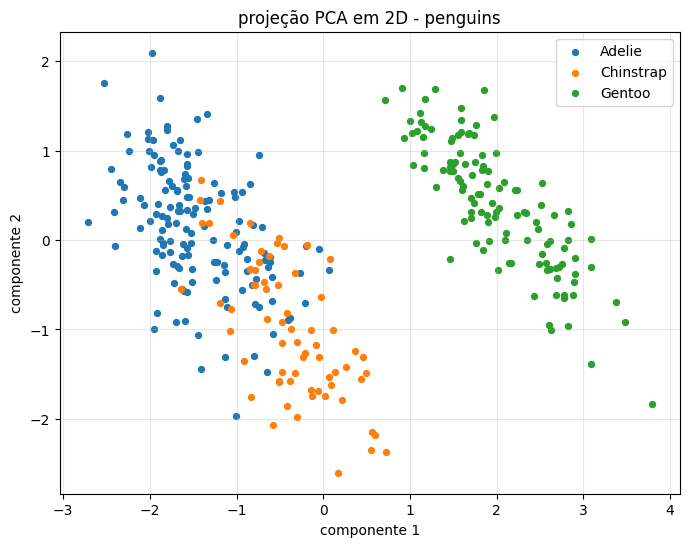

In [3]:
# item a) projeção em 2 dimensões

Z, _ = pca(Xn, 2)

especies = ['Adelie', 'Chinstrap', 'Gentoo']
plt.figure(figsize=(8, 6))
for c in range(3):
    plt.scatter(Z[y == c, 0], Z[y == c, 1], s=18, label=especies[c])
plt.xlabel('componente 1'); plt.ylabel('componente 2')
plt.title('projeção PCA em 2D - penguins')
plt.legend(); plt.grid(alpha=0.3); plt.show()

d = 1   variância explicada = 0.6863  (68.63%)
d = 2   variância explicada = 0.8809  (88.09%)
d = 3   variância explicada = 0.9730  (97.30%)
d = 4   variância explicada = 1.0000  (100.00%)


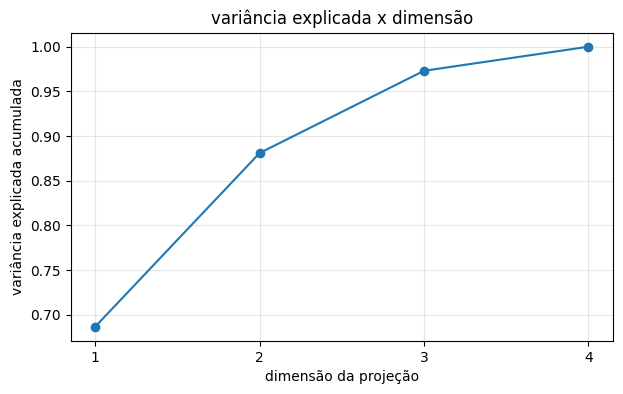

In [4]:
# item b) variância explicada para dimensão 1, 2, 3 e 4

_, var_explicada = pca(Xn, 4)

for d in [1, 2, 3, 4]:
    acumulada = var_explicada[:d].sum()
    print('d = %d   variância explicada = %.4f  (%.2f%%)' % (d, acumulada, acumulada * 100))

plt.figure(figsize=(7, 4))
plt.plot([1, 2, 3, 4], np.cumsum(var_explicada), 'o-')
plt.xlabel('dimensão da projeção'); plt.ylabel('variância explicada acumulada')
plt.title('variância explicada x dimensão'); plt.xticks([1, 2, 3, 4])
plt.grid(alpha=0.3); plt.show()